### **Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis (EDA) **  

#### **Problem Statement**  
In the fast-paced taxi booking industry, maximizing revenue is crucial for long-term success and driver satisfaction. Our goal is to leverage data-driven insights to optimize revenue streams for taxi drivers. Specifically, this research investigates whether payment methods influence fare prices by analyzing the relationship between payment type and fare amount.  

#### **Objective**  
The primary objective of this project is to conduct an **A/B test** to examine the relationship between total fare amount and the method of payment. Using **Python hypothesis testing** and **descriptive statistics**, we aim to uncover actionable insights that can help taxi drivers increase their earnings. In particular, we seek to determine whether there is a significant difference in fares between **credit card payments** and **cash payments**.  

#### **Research Question**  
**Does the total fare amount vary based on the payment method? Can we encourage customers to use payment methods that generate higher revenue for drivers, without negatively impacting their experience?**

**Importing Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
# Below code to display types of skewness:
from PIL import Image
from IPython.display import display
import statsmodels.api as sm
warnings.filterwarnings('ignore')

**Loading Dataset** //Company that provides data generally also provides meta data and it's description.



   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0       1.0  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0   
1       1.0  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0   
2       1.0  2020-01-01 00:47:41   2020-01-01 00:53:52              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.2         1.0                  N           238           239   
1            1.2         1.0                  N           239           238   
2            0.6         1.0                  N           238           238   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \
0           1.0          6.0    3.0      0.5        1.47           0.0   
1           1.0          7.0    3.0      0.5        1.50           0.0   
2           1.0          6.0    3.0      0.5        1.00           0.0   

   improvement_surcharge  total_amount  congestion_surcharge  
0                    0

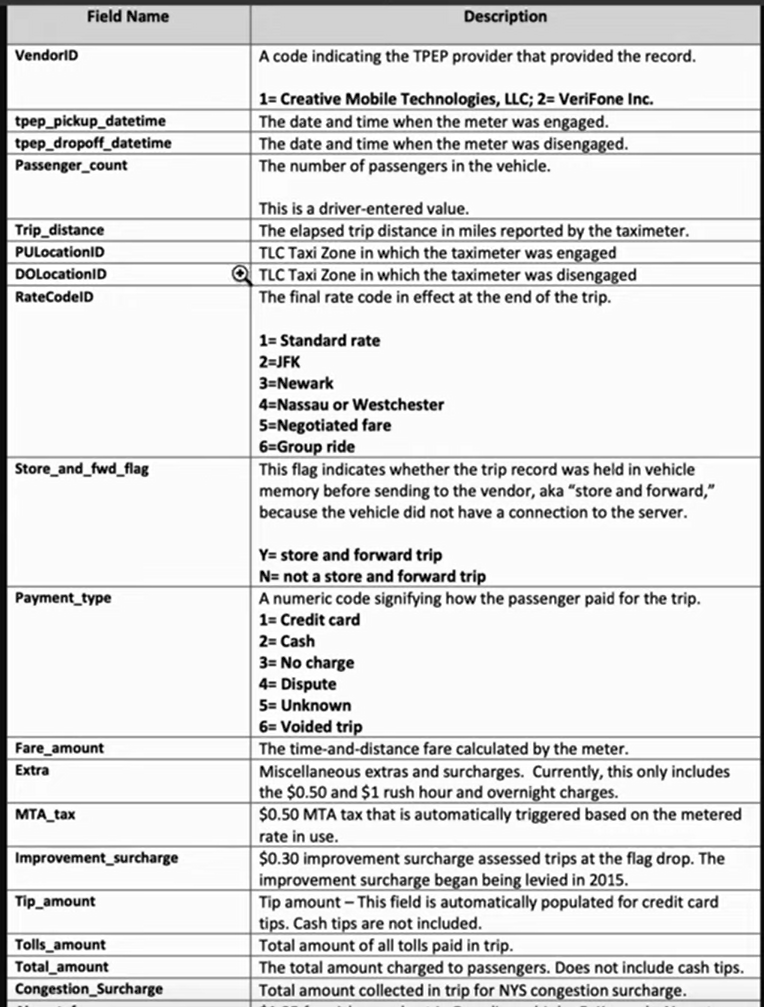

In [4]:
data = pd.read_csv(r'D:\Data Analyst\stats\tech classes\archive\yellow_tripdata_2020-01.csv')
print(data.head(3))
img = Image.open(r"D:\Data Analyst\stats\tech classes\archive\data_description.png")
# Display the image inline
display(img)

*** Exploratory Data Analysis ***

First we will drop uneccesary data we  don't need in analysis. But first we need to make sure if from some columsn can you extract any feature or not? Any information we haven't been given but present in features and can be extracted from other columns (through some calculation). 

Features (that can affect fare amount)
Distance
Duration

In [5]:
data.shape # total amount of data
# convert datetime objects to datatime data type
# data.dtypes
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])
# print(data['tpep_dropoff_datetime'].dtypes)

In [6]:
# extracting duration from drop and pickup columns
data['duration'] = data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']
data['duration'] = data['duration'].dt.total_seconds()/60
# print(data.head(1))

#Now remove unwanted columns
df = data[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration']]
df.head(1)
print(df.isnull().sum()) # checking amount of missing values. If null value is low percentage,
                            # if high % then try to fll

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
duration               0
dtype: int64


In [7]:
print(f'{(65441/len(df)* 100):.2f}', "%")
# Since only 1% of data is missing we can simply drop
df.dropna(inplace=True) # drop null data
df

1.02 %


,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.0,1.20,4.800000
1,1.0,1.0,7.0,1.20,7.416667
2,1.0,1.0,6.0,0.60,6.183333
3,1.0,1.0,5.5,0.80,4.850000
4,1.0,2.0,3.5,0.00,2.300000
...,...,...,...,...,...
6339562,1.0,1.0,11.0,2.10,14.233333
6339563,1.0,1.0,13.0,2.13,19.000000
6339564,1.0,1.0,12.5,2.55,16.283333
6339565,1.0,2.0,8.5,1.61,9.633333


In [8]:
# change passenger count and payment type to integers
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')
df.head(3)

# Remeber to present properly when in company "BE PROFESSIONAL"     
# Remove duplication
print(df.duplicated()) # we had removed other columns like vendor id and what not which is why duplicates
# are appearing. Duplicate value do not contribute in analysis, so you can simple drop them. 
df.drop_duplicates(inplace=True) #Dropping duplicates
df.shape

0          False
1          False
2          False
3          False
4          False
           ...  
6339562     True
6339563    False
6339564    False
6339565     True
6339566    False
Length: 6339567, dtype: bool


(3007861, 5)

# Now we will check contribution of passenger count and other columns or DISTRIBUTION of them


In [9]:
print(df['passenger_count'].value_counts(normalize=True)*100, "%") # percentage 



passenger_count
1    58.198102
2    19.035022
3     6.636011
5     6.293675
6     3.927176
4     3.604621
0     2.303298
7     0.000931
9     0.000598
8     0.000565
Name: proportion, dtype: float64 %


# You can say that as instances where total passengers in a single trip is 7, 8 or 9 is very low and trips where there were no passengers present is impossible they are outliers. Don't contribute in data as much. 

In [10]:
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 6)]
df = df[df['payment_type'] < 3]
print(df['passenger_count'].value_counts(normalize=True)*100, "%") # percentage 
print(df['payment_type'].value_counts(normalize=True)*100, "%") # percentage 
df.shape


passenger_count
1    61.877082
2    20.350338
3     7.119635
5     6.790172
4     3.862772
Name: proportion, dtype: float64 %
payment_type
1    68.61895
2    31.38105
Name: proportion, dtype: float64 %


(2780283, 5)

In [11]:
# payment type to cash and credit
df['payment_type'].replace([1,2], ['Card', 'Cash'], inplace=True)
df.head(3)

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.2,4.800000
1,1,Card,7.0,1.2,7.416667
2,1,Card,6.0,0.6,6.183333


In [12]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,1.780567e+01,4.536729e+00,2.415478e+01
std,1.176652e+00,1.506997e+01,4.895890e+00,9.260031e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.883333e+00
50%,1.000000e+00,1.300000e+01,2.730000e+00,1.573333e+01
75%,2.000000e+00,2.100000e+01,5.470000e+00,2.336667e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


In [13]:
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]
df = df[df['duration']>0]
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.748932e+06,2.748932e+06,2.748932e+06,2.748932e+06
mean,1.738151e+00,1.766835e+01,4.583313e+00,2.418261e+01
std,1.179440e+00,1.447531e+01,4.897806e+00,9.272285e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,9.000000e+00,1.530000e+00,9.950000e+00
50%,1.000000e+00,1.300000e+01,2.770000e+00,1.575000e+01
75%,2.000000e+00,2.100000e+01,5.500000e+00,2.333333e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


In [14]:
print(df['passenger_count'].value_counts(normalize=True)*100, "%") # percentage 
print(df['payment_type'].value_counts(normalize=True)*100, "%") # percentage 

passenger_count
1    61.647433
2    20.465475
3     7.163291
5     6.851679
4     3.872122
Name: proportion, dtype: float64 %
payment_type
Card    68.54673
Cash    31.45327
Name: proportion, dtype: float64 %


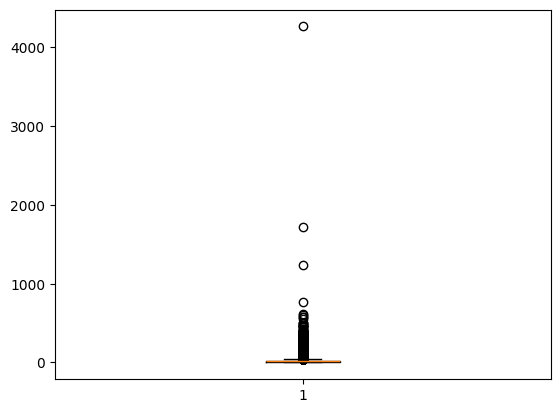

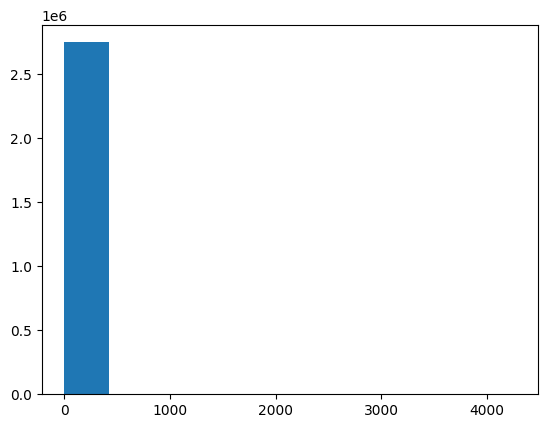

In [15]:
plt.boxplot(df['fare_amount'])
plt.show()
plt.hist(df['fare_amount'])
plt.show()

# since a lot of outliers, like 4000 value, we can remove outlers
# we use either Z SCORE or INTER QUARTILE RANGE (This one for now, since not much normally distributed where we can use z score)

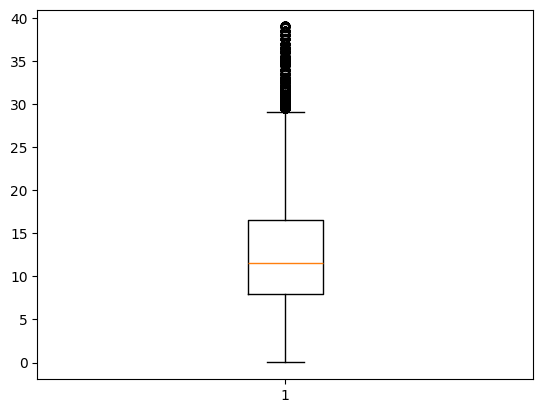

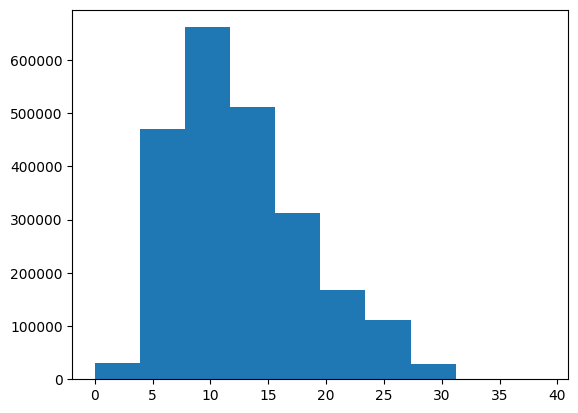

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.20,4.800000
1,1,Card,7.0,1.20,7.416667
2,1,Card,6.0,0.60,6.183333
3,1,Card,5.5,0.80,4.850000
5,1,Cash,2.5,0.03,0.883333
...,...,...,...,...,...
6339550,4,Card,10.5,2.40,12.383333
6339555,3,Card,10.0,2.09,14.800000
6339561,1,Card,17.5,4.11,21.500000
6339563,1,Card,13.0,2.13,19.000000


In [16]:
for col in ['fare_amount', 'trip_distance', 'duration']: 
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    lower_fence = q1 - 1.5*IQR
    upper_fence = q3 + 1.5*IQR
    # print(q1,q3,IQR, upper_fence, lower_fence, "for: ", col)

    df = df[ ( df [ col ] >= lower_fence ) & ( df [ col ] <= upper_fence ) ]

plt.boxplot(df['fare_amount'])
plt.show()
plt.hist(df['fare_amount'])
plt.show()
df

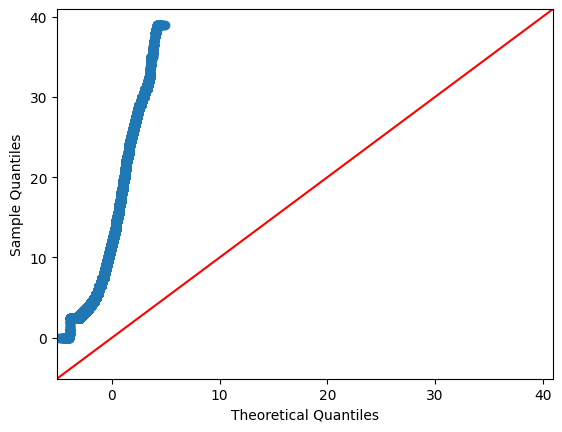

In [17]:
sm.qqplot(df['fare_amount'], line = '45')
plt.show()

In [18]:
print(df['passenger_count'].value_counts(normalize=True)*100, "%") # percentage 
print(df['payment_type'].value_counts(normalize=True)*100, "%") # percentage 

passenger_count
1    59.610524
2    21.024906
3     7.699090
5     7.470752
4     4.194728
Name: proportion, dtype: float64 %
payment_type
Card    67.323801
Cash    32.676199
Name: proportion, dtype: float64 %


# Now we use visualization to conclude certain things. Like does distance and fare amount affects payment method ? We will use HISTOGRAM. We'll make two plots for both, payment type and distance.

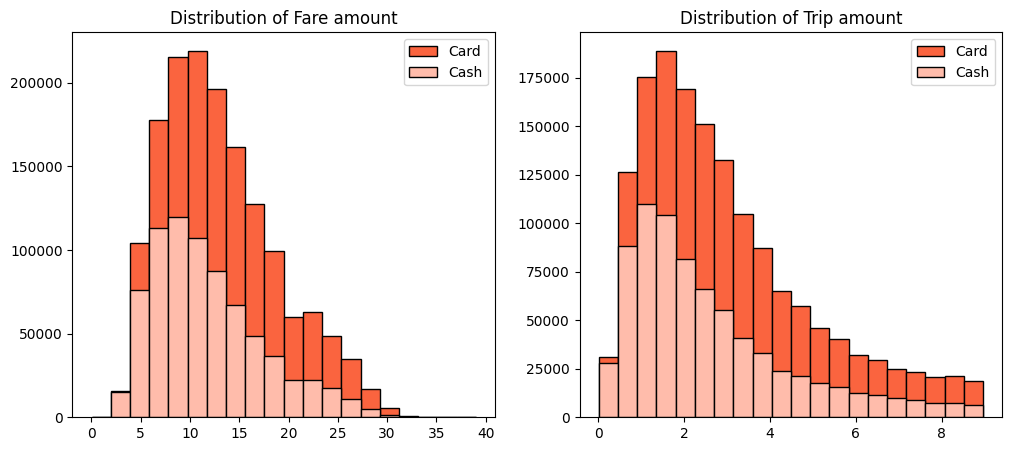

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

# first histogram bases on fare amount with card/cash as legend
# for card first we'll take filtered data
plt.title('Distribution of Fare amount')
plt.hist(df[df['payment_type'] == 'Card']['fare_amount'], histtype='barstacked', bins=20, edgecolor = 'k', color = '#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash']['fare_amount'], histtype='barstacked', bins=20, edgecolor = 'k', color = '#FFBCAB', label='Cash')
plt.legend()


plt.subplot(1,2,2)
plt.title('Distribution of Trip amount')
plt.hist(df[df['payment_type'] == 'Card']['trip_distance'], histtype='barstacked', bins=20, edgecolor = 'k', color = '#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash']['trip_distance'], histtype='barstacked', bins=20, edgecolor = 'k', color = '#FFBCAB', label='Cash')
plt.legend()


plt.show()

# As we can see mean and std deviation of card is greater for fare amount and trip_distance. This tells us if fair amount is higher or trip distance is higher customers prefer to pay over card. 

In [20]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'], 'trip_distance':['mean','std']})

fare_amount           trip_distance         
                    mean       std          mean      std
payment_type                                             
Card           13.112493  5.849281      2.992237  1.99274
Cash           11.758005  5.613038      2.602207  1.91372

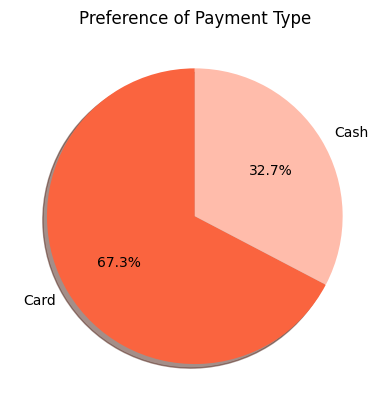

In [21]:
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize = True), labels = df['payment_type'].value_counts().index, 
        startangle=90, shadow=True, autopct = '%1.1f%%', colors = ['#FA643F', '#FFBCAB'])

plt.show()

# Does passenger count effectss fare? Using stacked bar chart with propotional representation

In [22]:
passenger_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count':'count'}, inplace=True)
passenger_count.reset_index(inplace = True)

In [23]:
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum())*100
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,909245,39.568381
1,Card,2,327661,14.259100
2,Card,3,122412,5.327106
3,Card,4,63676,2.771042
4,Card,5,124045,5.398171
5,Cash,1,460550,20.042143
6,Cash,2,155472,6.765806
7,Cash,3,54506,2.371984
8,Cash,4,32715,1.423686
9,Cash,5,47626,2.072581


In [24]:
df_temp = pd.DataFrame(columns = ['payment_type', 1, 2, 3, 4, 5])
df_temp['payment_type'] = ['Card', 'Cash']
df_temp.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df_temp.iloc[1,1:] = passenger_count.iloc[5:,-1]
df_temp

,payment_type,1,2,3,4,5
0,Card,39.568381,14.2591,5.327106,2.771042,5.398171
1,Cash,20.042143,6.765806,2.371984,1.423686,2.072581


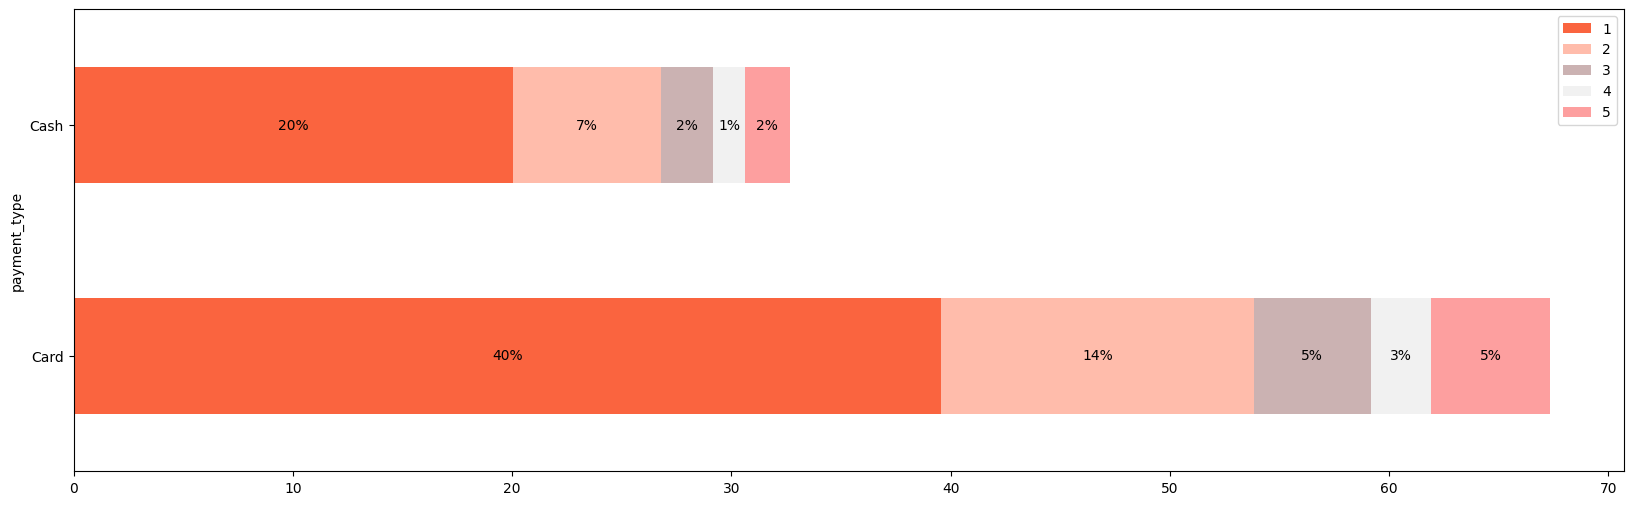

In [25]:
fig, ax = plt.subplots(figsize=(20,6))

df_temp.plot(x = 'payment_type', kind = 'barh', stacked=True, ax = ax, 
        color = ['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F'])

# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center')
    
plt.show()

# To prove it we will use hypothesis testing

# Null Hypothesis: There is no difference in average fare between cash and card paying customers.
# Alternate Hypothesis: There is a difference in average fare bewteen cash and card using customers.

As for the test. Data is continous so no chi sqaure test. Anova is where two or more groups. So no Anova test. Rest is z and t test. We don't have population standard deviation, only data for a few customers out of which we already eliminated half of them. So t test seems to be the way to go. To check for normality we wil draw QQ plot. That is one of the conditions to perform z test. If QQ plot aligns with diagonal, it is normaly distributed. Since we drew qq plot above and found out data wasn't normally distributed, WE WILL PERFOMR T TEST!  

In [26]:
card_sample = df [ df[ 'payment_type' ] == 'Card' ][ 'fare_amount' ]
cash_sample = df [ df[ 'payment_type' ] == 'Cash' ][ 'fare_amount' ]

In [27]:
t_stats, p_value = st.ttest_ind ( a = card_sample, b = cash_sample, equal_var = False )
print('T Statistics: ', t_stats, 'P-Value: ', p_value)

T Statistics:  169.2111527245052 P-Value:  0.0


# THere is significant difference between averages fare in card and cash payments. We reject H0, accept H1. Since p value < alpha. 0.0 < 0.05